🧠 1. IMPORT LIBRARIES

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Better visuals
sns.set(style="whitegrid")

📂 2. LOAD DATA


In [4]:
df = pd.read_csv("../data/maternal_health.csv")

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


🔍 3. DATA OVERVIEW

In [5]:
print("Shape of dataset:", df.shape)
df.info()
df.describe()

Shape of dataset: (1014, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 63.8 KB


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


The dataset contains 1014 records and 7 features.
There are no missing values, and most features are numerical, making the dataset clean and ready for analysis.

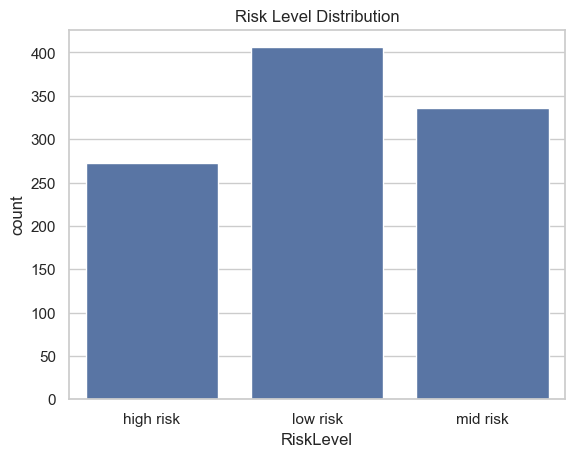

In [6]:
# 4. Target Variable Analysis
# ================================
plt.figure()
sns.countplot(x='RiskLevel', data=df)
plt.title("Risk Level Distribution")
plt.show()


I analyzed the distribution of the target variable.
All three classes are present, with slight imbalance, which is acceptable for classification.

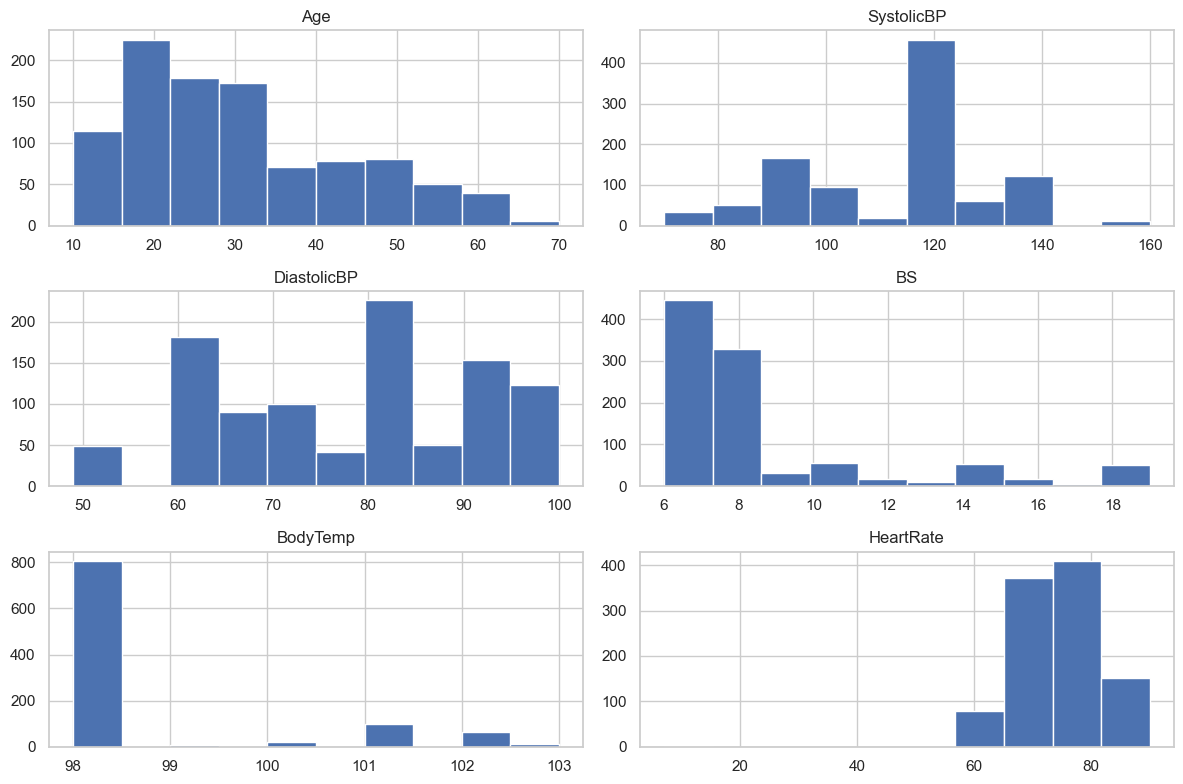

In [7]:
# ================================
# 5. Feature Distribution
# ================================
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()



I visualized the distribution of all numerical features.
Most features show a reasonable spread, while blood sugar (BS) shows higher variation compared to others.

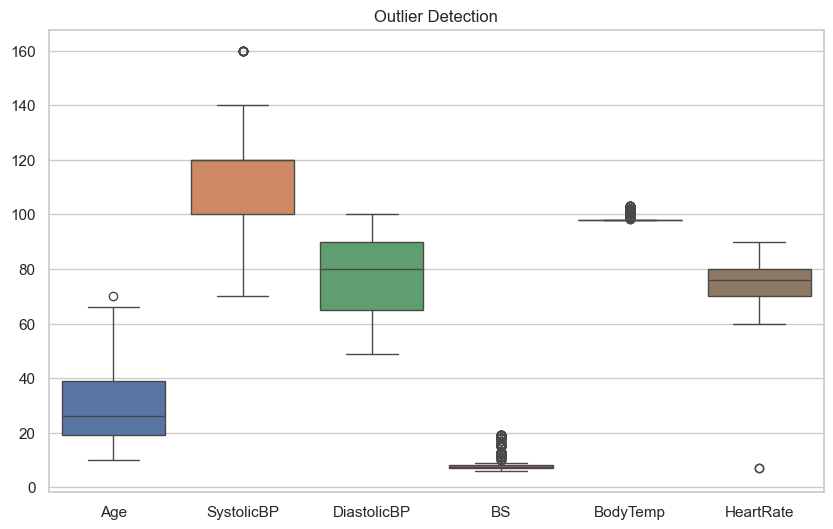

In [8]:
# 6. Outlier Detection
# ================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.title("Outlier Detection")
plt.show()



I used boxplots to detect outliers in the dataset.
Some features like blood pressure and blood sugar contain extreme values, which may influence model performance.

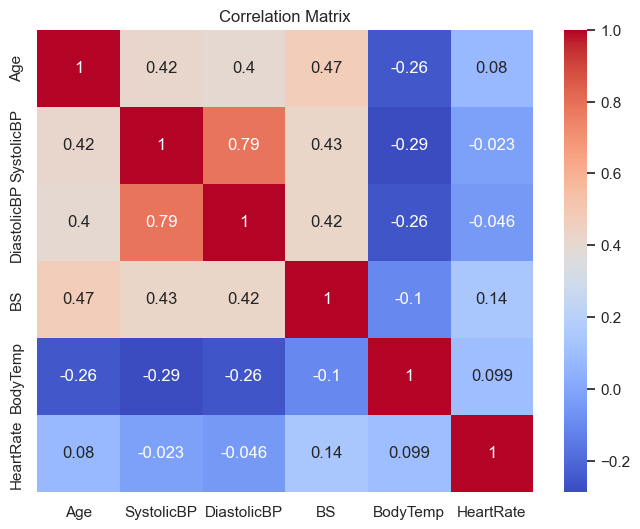

In [9]:
# ================================
# 7. Correlation Analysis
# ================================
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

I plotted a correlation matrix to understand relationships between features.
Blood pressure and blood sugar show moderate relationships, indicating their importance in prediction.


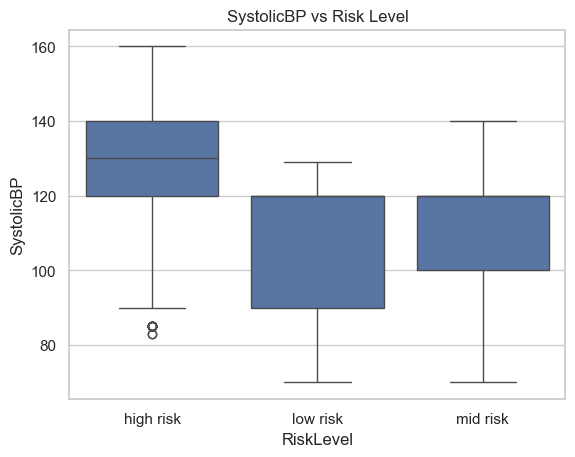

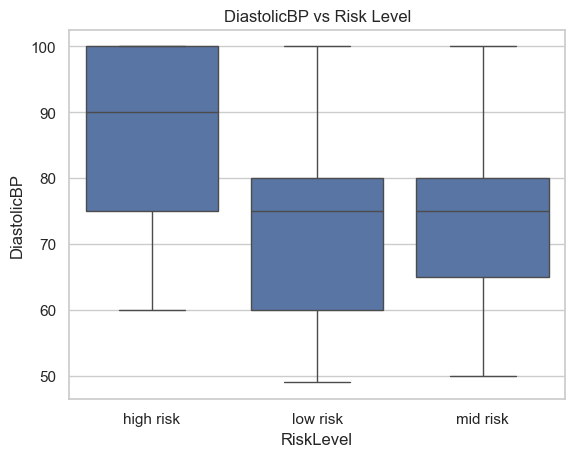

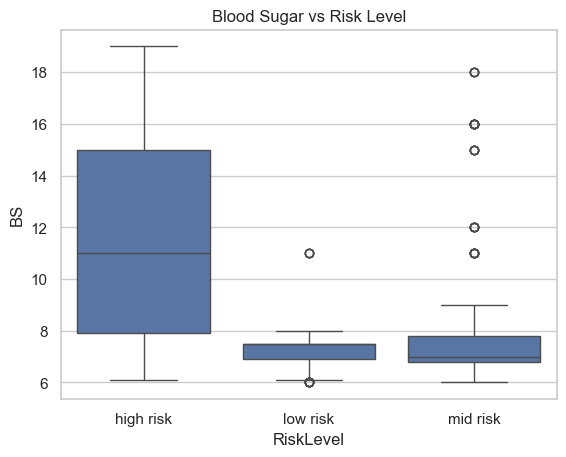

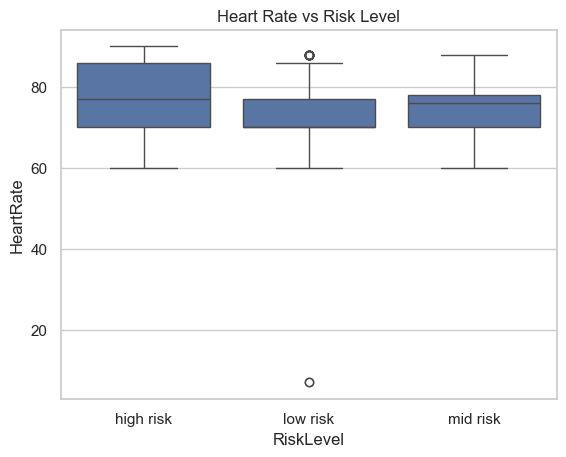

In [10]:
# ================================
# 8. Feature vs Target Analysis
# ================================
plt.figure()
sns.boxplot(x='RiskLevel', y='SystolicBP', data=df)
plt.title("SystolicBP vs Risk Level")
plt.show()

plt.figure()
sns.boxplot(x='RiskLevel', y='DiastolicBP', data=df)
plt.title("DiastolicBP vs Risk Level")
plt.show()

plt.figure()
sns.boxplot(x='RiskLevel', y='BS', data=df)
plt.title("Blood Sugar vs Risk Level")
plt.show()

plt.figure()
sns.boxplot(x='RiskLevel', y='HeartRate', data=df)
plt.title("Heart Rate vs Risk Level")
plt.show()


I observed that higher systolic blood pressure is mostly associated with high-risk patients.
This indicates that SystolicBP is an important feature for predicting risk.

Diastolic blood pressure is also higher in high-risk cases.
This confirms that both BP components are strong indicators of maternal risk.

Blood sugar levels are significantly higher in high-risk patients.
This shows that BS is one of the most important features in determining risk level.

Heart rate shows some variation across risk levels but is less distinct compared to BP and BS.
This suggests it has moderate importance in prediction.


In [11]:
# ================================
# 9. Class Balance Check
# ================================
print("\nClass Distribution:\n")
print(df['RiskLevel'].value_counts())



Class Distribution:

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


The dataset shows a slight imbalance between risk classes.
Therefore, evaluation metrics like recall will be more important than accuracy alone.

In [12]:
# ================================
# 10. Feature Engineering (EDA Purpose)
# ================================
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 20, 35, 50], labels=[0, 1, 2])

df["MeanBP"] = (df["SystolicBP"] + df["DiastolicBP"]) / 2

df["RiskScore"] = (
    df["SystolicBP"] * 0.25 +
    df["DiastolicBP"] * 0.25 +
    df["BS"] * 0.2 +
    df["BodyTemp"] * 0.15 +
    df["HeartRate"] * 0.15
)

df.head()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,AgeGroup,MeanBP,RiskScore
0,25,130,80,15.0,98.0,86,high risk,1,105.0,83.10
1,35,140,90,13.0,98.0,70,high risk,1,115.0,85.30
2,29,90,70,8.0,100.0,80,high risk,1,80.0,68.60
3,30,140,85,7.0,98.0,70,high risk,1,112.5,82.85
4,35,120,60,6.1,98.0,76,low risk,1,90.0,72.32


I created new features such as AgeGroup, MeanBP, and RiskScore.
These features help capture combined health effects and improve model performance.

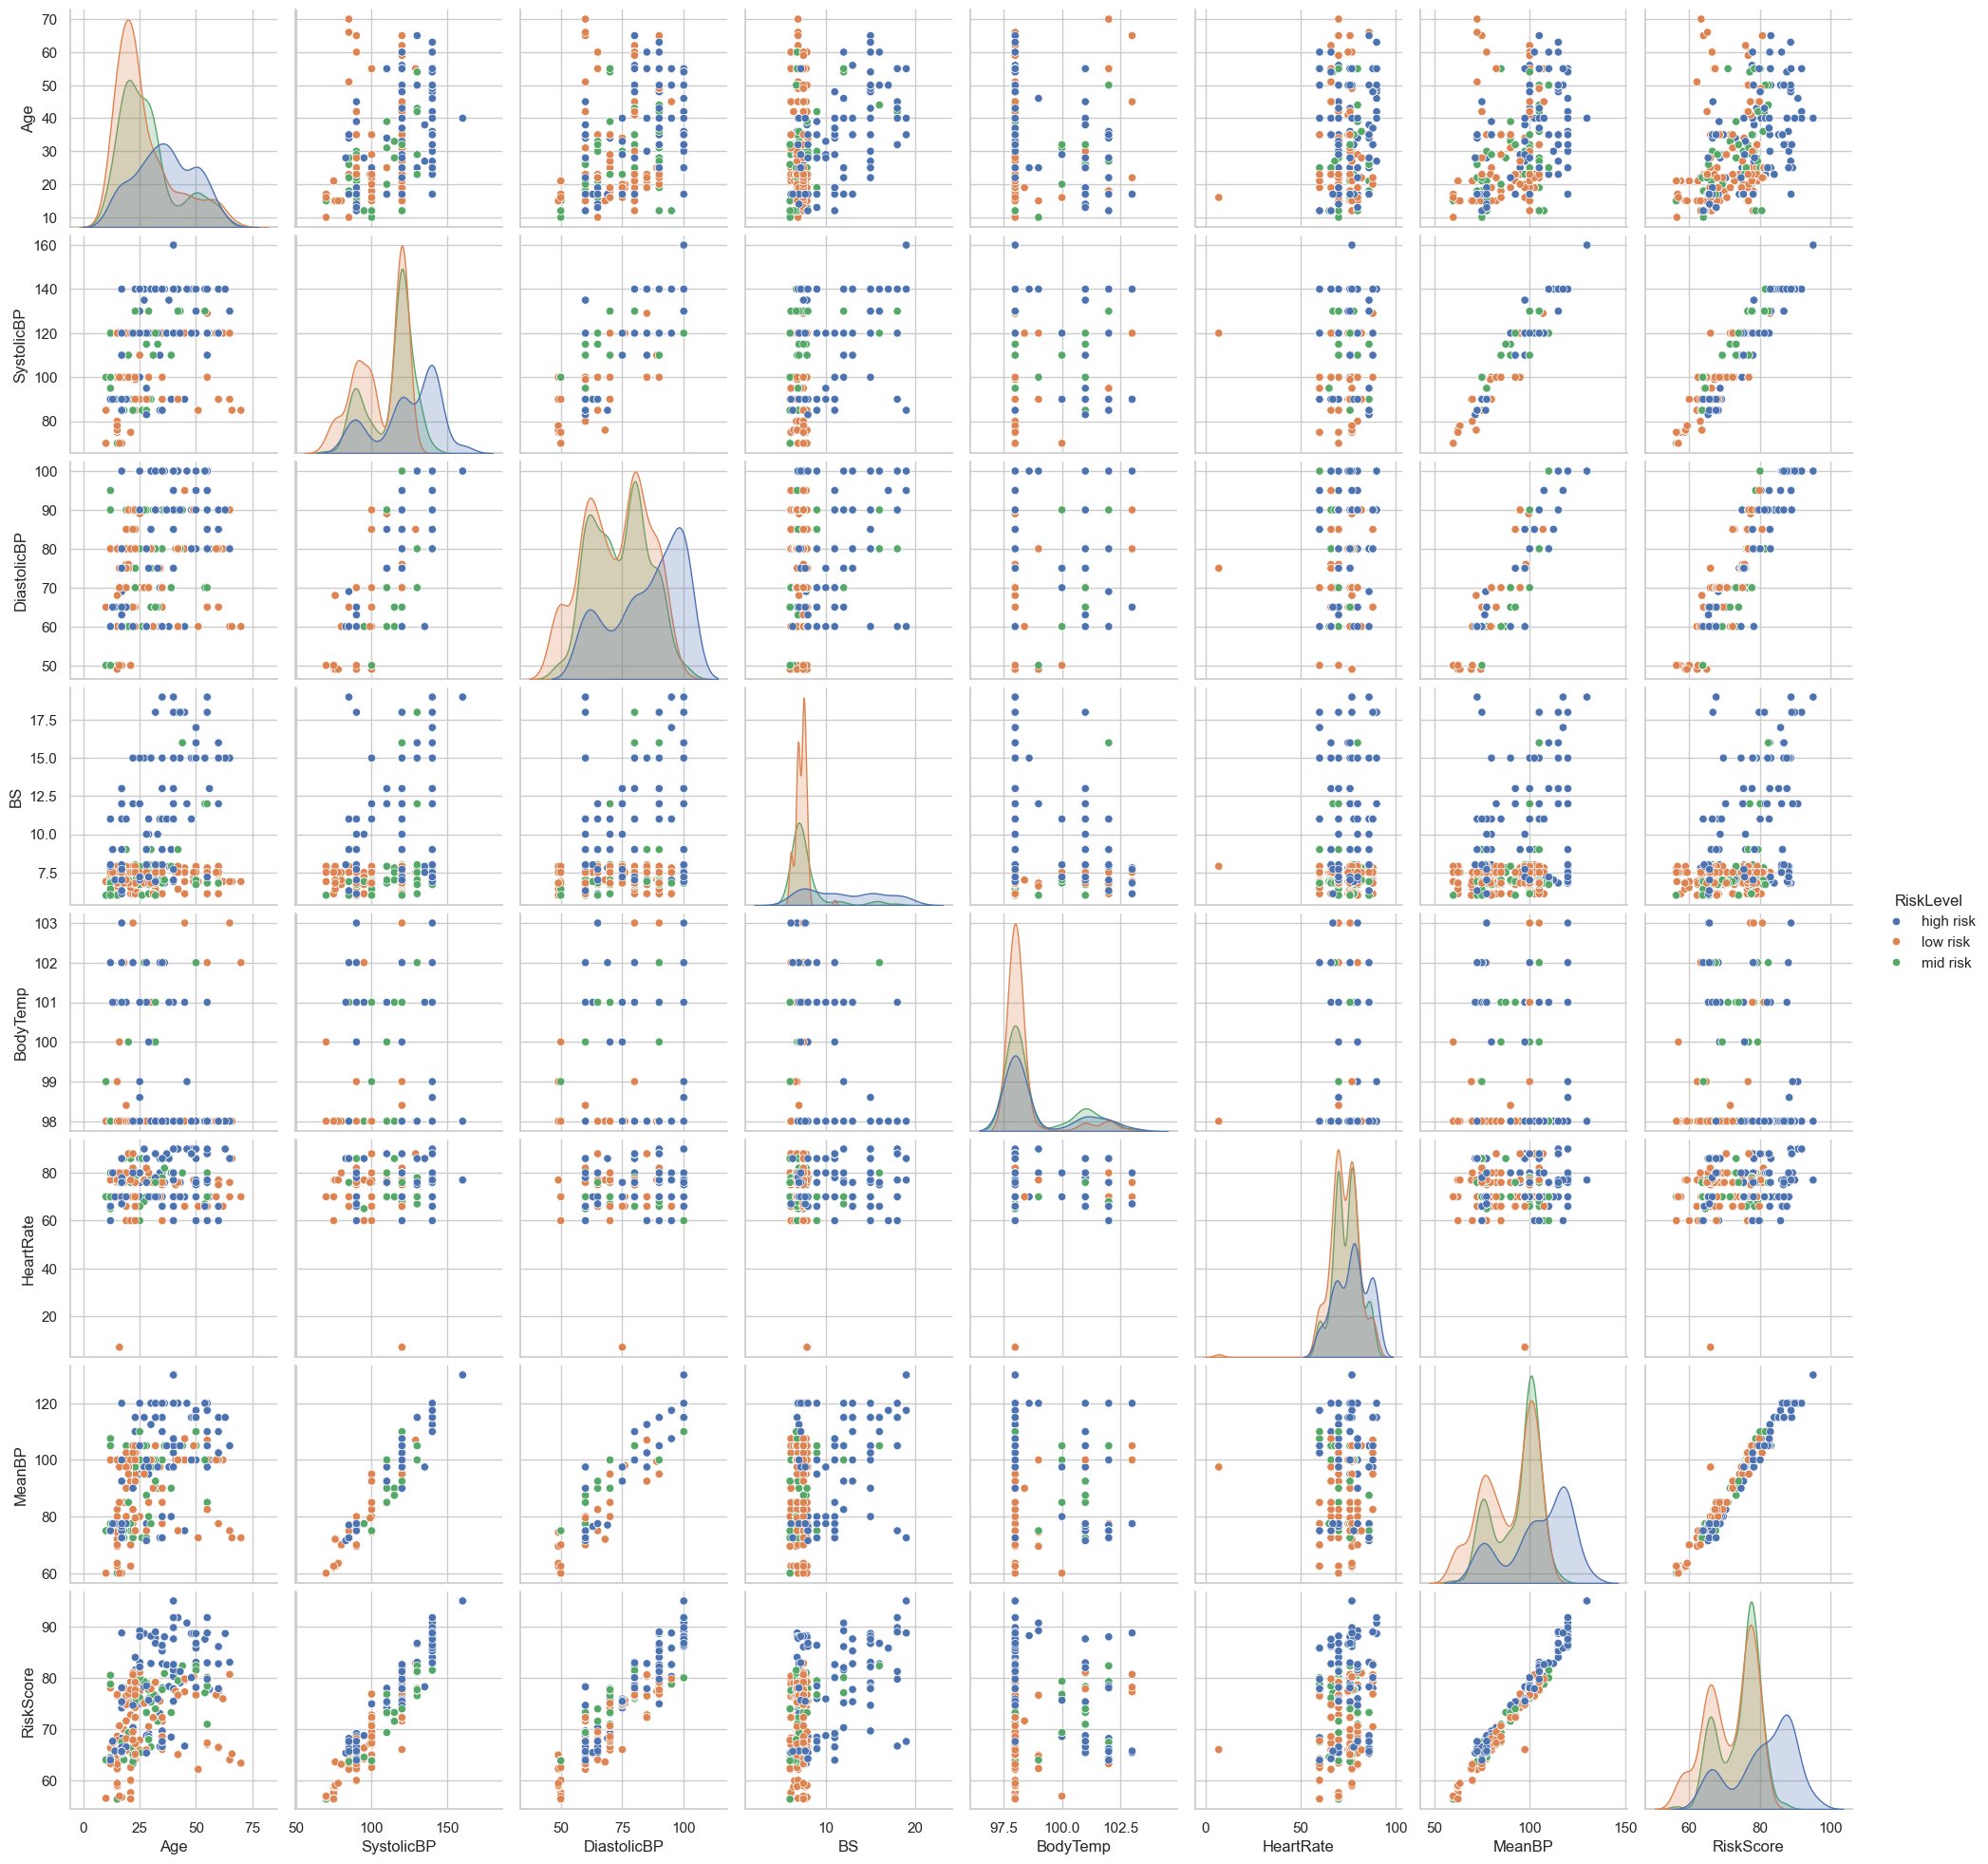

In [13]:
# ================================
# 11. Advanced Visualization
# ================================
sns.pairplot(df, hue='RiskLevel')
plt.show()



The pairplot helps visualize relationships between multiple features simultaneously.
It shows clear separation patterns for some features, especially BP and BS, across risk levels.

In [14]:
# ================================
# 12. Key Insights (Print Output)
# ================================
print("\nKey Insights:")
print("1. Blood pressure (Systolic & Diastolic) strongly influences risk level.")
print("2. Blood sugar (BS) is a major indicator of high risk.")
print("3. High-risk cases generally have higher BP and BS values.")
print("4. Feature engineering like MeanBP and RiskScore captures combined health effects.")
print("5. Dataset is clean with no missing values and suitable for modeling.")


Key Insights:
1. Blood pressure (Systolic & Diastolic) strongly influences risk level.
2. Blood sugar (BS) is a major indicator of high risk.
3. High-risk cases generally have higher BP and BS values.
4. Feature engineering like MeanBP and RiskScore captures combined health effects.
5. Dataset is clean with no missing values and suitable for modeling.
